In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
#monthly production rates according to HUR
bm_iskanderM = 60
bm_kinzhal = 15
bm_kn23 = 0

cm_iskanderK = 20
cm_kh101 = 60
cm_calibr = 60

bm_prod = bm_iskanderM + bm_kinzhal + bm_kn23
cm_prod = cm_calibr + cm_iskanderK + cm_kh101

geran2 = 2700
gerbera = 2500

as_kh32 = 10
sta_s300 = 100

In [3]:
#stockpile as of June 2025 according to HUR
Sbm_iskanderM = 500
Sbm_kn23 = 60
Sbm_kinzhal = 150

Scm_iskanderK = 300
Scm_kh101 = 260
Scm_calibr = 400

Ssta_s300 = 11000 
Sas_kh32 = 280

Sgeran2 = 6000
Sgerbera = 6000

bm_stock = Sbm_iskanderM + Sbm_kinzhal + Sbm_kn23
cm_stock = Scm_calibr + Scm_iskanderK + Scm_kh101

In [4]:
def calculate_stockpile(i_stock,prod,launches,period):
    stock = np.zeros(period+1)
    stock[0] = i_stock
    for i in range(period):
        stock[i+1] = stock[i]+prod-launches[i]
    return stock
        

In [24]:
period = 8 #months

In [25]:
#overnight launches
drones = np.array([5025, 6317, 4146, 5599, 5401, 5311, 5336, 4327, 5092])
bm = np.array([56, 58, 49, 25, 97, 90, 56, 75, 116])
cm = np.array([154, 109, 99, 153, 135, 104, 122, 56, 140])
aagm = np.array([4, 24, 7, 10, 4, 16, 0, 1, 1])
agm = np.array([17, 7, 0, 1, 29, 4, 0, 0, 15])
asm = np.array([0, 0, 0, 1, 0, 1, 0, 3, 14])
arm = np.array([4, 0, 0, 0, 0, 0, 0, 0, 0])

In [68]:
ballistic_stockpile = calculate_stockpile(bm_stock,bm_prod,bm,period)
cruise_stockpile = calculate_stockpile(cm_stock,cm_prod,cm,period)
shahed_stockpile = calculate_stockpile(Sgeran2,geran2,drones*0.6,period)
decoy_stockpile = calculate_stockpile(Sgerbera, gerbera, drones*0.4, period)
s300_stockpile = calculate_stockpile(Ssta_s300,sta_s300,asm+aagm,period)
aircraft_guided = calculate_stockpile(Sas_kh32,as_kh32,agm,period)

In [70]:
print(shahed_stockpile)
print(decoy_stockpile)
print(ballistic_stockpile)
print(cruise_stockpile)
print(s300_stockpile)

[6000.  5685.  4594.8 4807.2 4147.8 3607.2 3120.6 2619.  2722.8]
[6000.  6490.  6463.2 7304.8 7565.2 7904.8 8280.4 8646.  9415.2]
[710. 729. 746. 772. 822. 800. 785. 804. 804.]
[ 960.  946.  977. 1018. 1005. 1010. 1046. 1064. 1148.]
[11000. 11096. 11172. 11265. 11354. 11450. 11533. 11633. 11729.]


In [91]:
print(np.average(shahed_stockpile))

4144.933333333334


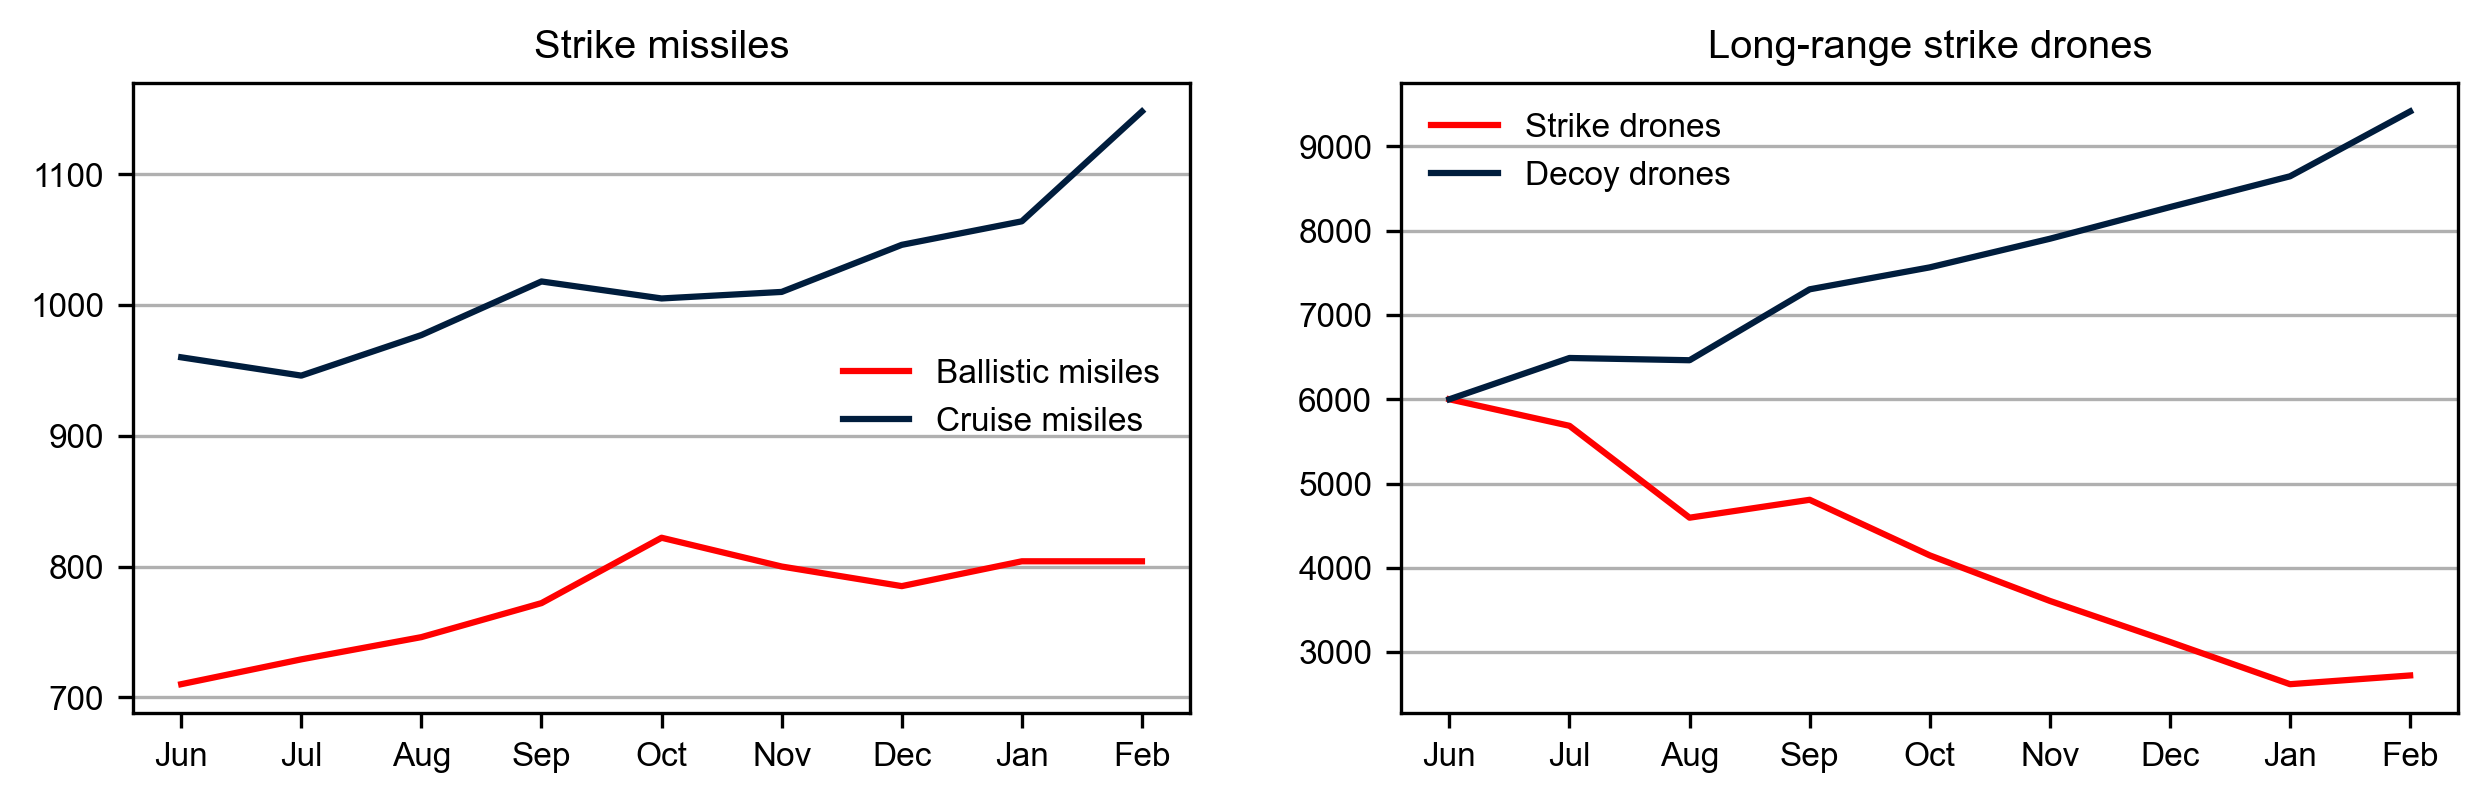

In [104]:
x = np.arange(0,9)

months = [ "Jun", "Jul","Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb"]

fig = plt.figure(figsize = (10,6),dpi=300)
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams.update({'font.size': 8})
gs = fig.add_gridspec(2,2)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
# ax3 = fig.add_subplot(gs[1,0])

ax1.plot(x,ballistic_stockpile,label="Ballistic misiles",color="red")
ax1.plot(x,cruise_stockpile,label="Cruise misiles",color = "#001d3d")
ax1.set_xticks(x)
ax1.set_xticklabels(months)
ax1.grid(axis="y")
ax1.set_title("Strike missiles")
ax1.legend(frameon=False,loc="center right")

ax2.set_title("Long-range strike drones")
ax2.plot(x,shahed_stockpile, label = "Strike drones",color="red")
ax2.plot(x,decoy_stockpile, label = "Decoy drones",color ="#001d3d")
ax2.grid(axis="y")
ax2.legend(frameon=False)
ax2.set_xticks(x)
ax2.set_xticklabels(months)

# ax3.set_title("S-300 air defence missiles")
# ax3.plot(x,s300_stockpile, label = "S-300 air defence missiles")
# ax3.set_xticks(x)
# ax3.set_xticklabels(months)
# plt.tight_layout()
# plt.show()

plt.savefig("MonthOnMonth")